# Phase 2 — Baseline A: Faster R-CNN

**MalariAI · Kaysarul Anas Apurba · Laurentian University**

---

## What this phase produces

A fully trained **Faster R-CNN ResNet-50 FPN** object detector on the NIH BBBC041 dataset. This is **Pipeline A** — the end-to-end baseline we will beat with Pipeline B.

Outputs:
- `Phase2-BaselineA/checkpoints/best.pth` — best checkpoint by validation loss
- `Phase2-BaselineA/checkpoints/metrics.json` — mAP@0.5 + per-class AP for each class
- Loss curves plotted inline

---

## Why Faster R-CNN as the baseline?

Faster R-CNN (Ren et al., 2015) is the standard two-stage detector used in prior malaria detection work (Hung et al. 2018, Loh et al. 2021). It has three components:

1. **ResNet-50-FPN backbone** — extracts multi-scale features at 5 pyramid levels (P2–P6). The Feature Pyramid Network (FPN) allows detection of cells at very different sizes.
2. **Region Proposal Network (RPN)** — proposes ~2000 candidate bounding boxes per image using learned anchor priors.
3. **RoI Align + Classification Head** — for each proposal, aligns a fixed-size feature map and predicts class + refined box coordinates.

**Key limitation (motivates Pipeline B):** The RPN and classification head are trained under the *closed-world assumption* — any unannotated region is treated as background during training. In BBBC041, the majority of healthy RBCs are unannotated, so Faster R-CNN will learn to suppress them. This is **P1** from our problem statement.

Additionally, Non-Maximum Suppression (NMS) at inference time discards overlapping proposals — problematic in dense smears (**P2**).

This baseline exists to measure *how bad* P1 and P2 are, and to give Pipeline B a quantitative target to beat.


## 1. Environment & GPU Check

Faster R-CNN training requires a GPU. On CPU it would take 12–24 hours for 20 epochs over 966 images.

**Recommended: run this notebook on Kaggle (free T4/P100)**
- Upload this notebook to Kaggle
- Upload `training.json`, `test.json`, and `images/` as a Kaggle dataset
- Enable GPU accelerator in notebook settings

**`SMOKE_TEST = True`** runs 2 epochs on 60 images so you can verify the code works locally without waiting.


In [3]:
import torch

print(f'PyTorch : {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')

if device.type == 'cpu':
    print('\n⚠  No GPU detected.')
    print('   Set SMOKE_TEST = True below to run a quick 2-epoch check.')
    print('   For full training, upload to Kaggle and enable GPU.')
else:
    props = torch.cuda.get_device_properties(0)
    print(f'GPU     : {props.name}  ({props.total_memory // 1024**3} GB VRAM)')


PyTorch : 2.4.1+cu124
Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 Laptop GPU  (3 GB VRAM)


## 2. Imports

`torchmetrics` provides a COCO-standard `MeanAveragePrecision` implementation. We install it here if missing.


In [4]:
import subprocess, sys
try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
except ImportError:
    print('Installing torchmetrics ...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torchmetrics', '-q'], check=True)
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
print('torchmetrics OK')


torchmetrics OK


In [5]:
import json, time, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# ── Project paths ─────────────────────────────────────────────────────────
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'Phase1-EDA'))

from shared.label_map import (
    LABEL_TO_INT, INT_TO_LABEL, NUM_CLASSES,
    CLASS_COLOUR_RGB, PARASITE_CLASSES, SHORT_NAME,
)
from dataset import MalariaDataset, detection_collate

print('All imports OK')
print(f'NUM_CLASSES = {NUM_CLASSES}  (includes background at index 0)')


All imports OK
NUM_CLASSES = 7  (includes background at index 0)


## 3. Configuration

All hyperparameters live in one dict — easy to change for Kaggle runs.

**Why these values?**
- `batch_size = 2` — Faster R-CNN holds many intermediate tensors; 2 per GPU is the standard COCO recipe
- `lr = 5e-3` — SGD with warmup; the COCO Faster R-CNN recipe uses this with batch_size=2
- `val_split = 0.2` — 80/20 image-level split, same as our train/val protocol in §3.1
- `iou_threshold = 0.5` — PASCAL VOC standard; we also report COCO [0.5:0.95] at eval time


In [6]:
# ── Edit these before running ─────────────────────────────────────────────
SMOKE_TEST  = False   # True = 2 epochs on 60 images (CPU-safe sanity check)
                      # False = full training run (needs GPU)

JSON_TRAIN  = str(ROOT / 'data' / 'malaria' / 'training.json')
JSON_TEST   = str(ROOT / 'data' / 'malaria' / 'test.json')
IMG_DIR     = str(ROOT / 'data' / 'malaria' / 'images')
CKPT_DIR    = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

CFG = dict(
    # Training
    epochs        = 2   if SMOKE_TEST else 20,
    batch_size    = 2,
    lr            = 5e-3,
    momentum      = 0.9,
    weight_decay  = 1e-4,
    lr_step_size  = 10,    # StepLR: drop LR by gamma every N epochs
    lr_gamma      = 0.1,
    val_split     = 0.2,
    seed          = 42,
    # Data
    num_workers   = 0,     # 0 on Windows; increase on Linux/Kaggle
    smoke_n       = 60,    # images to use in SMOKE_TEST mode
    # Model
    num_classes   = NUM_CLASSES,   # 7 (background + 6 cell types)
    pretrained    = True,
    # Eval
    score_thresh  = 0.3,   # minimum confidence to count as detection
    nms_thresh    = 0.5,   # NMS IoU threshold (default is 0.5)
)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

mode = '🧪 SMOKE TEST (2 epochs, 60 images)' if SMOKE_TEST else '🚀 FULL TRAINING'
print(f'Mode    : {mode}')
print(f'Epochs  : {CFG["epochs"]}')
print(f'Device  : {device}')
print(f'Classes : {CFG["num_classes"]}  →  {[INT_TO_LABEL[i] for i in range(NUM_CLASSES)]}')


Mode    : 🚀 FULL TRAINING
Epochs  : 20
Device  : cuda
Classes : 7  →  ['background', 'red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte']


## 4. Dataset & DataLoaders

We reuse `MalariaDataset` from `Phase1-EDA/dataset.py` — it:
- Parses directly from the raw JSON (no CSV intermediary)
- Skips `"difficult"` annotations
- Skips degenerate boxes (x_max ≤ x_min etc.)
- Skips images with zero valid annotations
- Returns `(FloatTensor[3,H,W], {boxes, labels, image_id})`

The 80/20 train/val split is done at the **image level** (no image contributes boxes to both sets).


In [7]:
# Full dataset
full_ds = MalariaDataset(JSON_TRAIN, IMG_DIR)
print(f'Total images with valid annotations: {len(full_ds)}')

# 80/20 image-level split
n_val   = int(len(full_ds) * CFG['val_split'])
n_train = len(full_ds) - n_val
generator = torch.Generator().manual_seed(CFG['seed'])
train_ds, val_ds = random_split(full_ds, [n_train, n_val], generator=generator)

if SMOKE_TEST:
    smoke_idx = list(range(CFG['smoke_n']))
    train_ds  = Subset(full_ds, smoke_idx[:int(CFG['smoke_n']*0.8)])
    val_ds    = Subset(full_ds, smoke_idx[int(CFG['smoke_n']*0.8):])

print(f'Train images : {len(train_ds)}')
print(f'Val   images : {len(val_ds)}')

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'], shuffle=True,
    num_workers=CFG['num_workers'], collate_fn=detection_collate,
    pin_memory=(device.type == 'cuda'),
)
val_loader = DataLoader(
    val_ds, batch_size=CFG['batch_size'], shuffle=False,
    num_workers=CFG['num_workers'], collate_fn=detection_collate,
    pin_memory=(device.type == 'cuda'),
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

# Class counts in training split
print('\nClass distribution in train split:')
counts = defaultdict(int)
for idx in train_ds.indices if hasattr(train_ds, 'indices') else range(len(train_ds)):
    rec = full_ds._records[idx]
    for lbl in rec['labels']:
        counts[INT_TO_LABEL[lbl]] += 1
total = sum(counts.values())
for cls in [INT_TO_LABEL[i] for i in range(1, NUM_CLASSES)]:
    cnt = counts.get(cls, 0)
    print(f'  {cls:<22} {cnt:>7,}  ({100*cnt/max(total,1):5.1f}%)')


Total images with valid annotations: 1208
Train images : 967
Val   images : 241

Train batches : 484
Val   batches : 121

Class distribution in train split:
  red blood cell          61,641  ( 97.2%)
  trophozoite              1,170  (  1.8%)
  ring                       283  (  0.4%)
  schizont                   152  (  0.2%)
  gametocyte                 115  (  0.2%)
  leukocyte                   85  (  0.1%)


## 5. Visualise Training Samples with Ground-Truth Boxes

Quick sanity check — verify that the dataset returns correct images and boxes.
Colour coding matches our label map. Note the extreme RBC dominance visually.


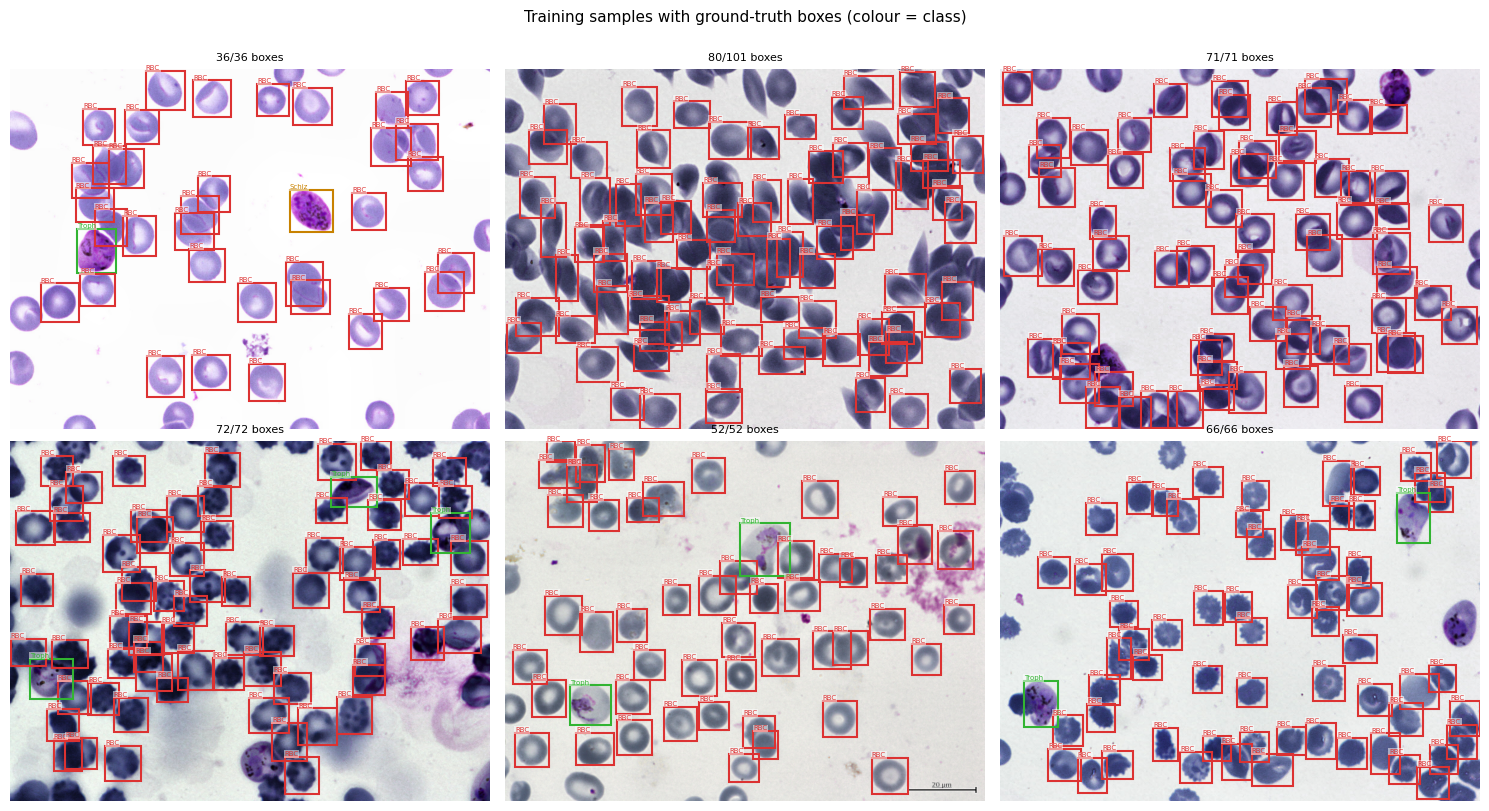

Saved → checkpoints/sample_gt_boxes.png


In [6]:
def draw_boxes(ax, image_tensor, target, max_boxes=80):
    """Draw GT bounding boxes on a matplotlib axis."""
    img = image_tensor.permute(1, 2, 0).numpy()
    ax.imshow(img)
    boxes  = target['boxes'].numpy()
    labels = target['labels'].numpy()
    for i, (box, lbl) in enumerate(zip(boxes, labels)):
        if i >= max_boxes: break
        x1, y1, x2, y2 = box
        cls_name = INT_TO_LABEL[lbl]
        r, g, b  = CLASS_COLOUR_RGB[cls_name]
        color    = (r/255, g/255, b/255)
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=1.5, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, max(y1-3, 0), SHORT_NAME[cls_name],
                fontsize=5, color=color,
                bbox=dict(facecolor='white', alpha=0.5, pad=0.5, linewidth=0))
    total_boxes = len(boxes)
    shown = min(max_boxes, total_boxes)
    ax.set_title(f'{shown}/{total_boxes} boxes', fontsize=8)
    ax.axis('off')

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sample_indices = random.sample(range(len(full_ds)), 6)
for ax, idx in zip(axes.flat, sample_indices):
    img, tgt = full_ds[idx]
    draw_boxes(ax, img, tgt)
plt.suptitle('Training samples with ground-truth boxes (colour = class)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('checkpoints/sample_gt_boxes.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/sample_gt_boxes.png')


## 6. Building the Model — Faster R-CNN ResNet-50 FPN

We load the COCO-pretrained `fasterrcnn_resnet50_fpn` and replace only the **classification head** (the `roi_heads.box_predictor`) with a new `FastRCNNPredictor` for our 7 classes.

The rest of the network — ResNet-50 backbone, FPN neck, RPN — starts from COCO weights, which gives us strong anchor features without training from scratch.

**Why not freeze the backbone?**  
Our cells are ~108×107 px on 1600×1200 images. COCO objects are much larger. The FPN's low-level features (P2, P3) need fine-tuning to detect small circular objects. Freezing would hurt performance.

**Anchor sizes note:**  
Default FPN anchors cover 32→512 px with 3 aspect ratios. Our cells are roughly square at 108 px — the P3 level (128 px anchors) matches well. No anchor customisation needed.


In [7]:
def build_model(num_classes: int, pretrained: bool = True) -> torch.nn.Module:
    """
    Faster R-CNN with ResNet-50 FPN backbone.
    Replaces the default 91-class COCO head with a num_classes head.
    """
    weights = FasterRCNN_ResNet50_FPN_Weights.COCO_V1 if pretrained else None
    model   = fasterrcnn_resnet50_fpn(weights=weights)

    # Replace the box classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features  # 1024
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model


model = build_model(CFG['num_classes'], pretrained=CFG['pretrained'])
model.to(device)

# Parameter count
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Backbone in_features (RoI head input): '
      f'{model.roi_heads.box_predictor.cls_score.in_features}')
print(f'Output classes: {model.roi_heads.box_predictor.cls_score.out_features}')
print(f'\nModel ready on: {next(model.parameters()).device}')


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\taiba/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100.0%


Total parameters    : 41,324,786
Trainable parameters: 41,102,386
Backbone in_features (RoI head input): 1024
Output classes: 7

Model ready on: cuda:0


## 7. Training & Validation Functions

Faster R-CNN's training API is different from a classifier:
- `model.train()` + pass `(images, targets)` → returns **a dict of losses** (not logits)
- `model.eval()` + pass `images` only → returns **a list of prediction dicts**

The four losses returned during training:
- `loss_classifier` — cross-entropy on RoI class predictions
- `loss_box_reg` — smooth-L1 on RoI box refinement
- `loss_objectness` — RPN binary foreground/background
- `loss_rpn_box_reg` — RPN box regression

We sum all four for the backward pass.


In [8]:
def train_one_epoch(model, loader, optimizer, device, epoch, print_freq=50):
    model.train()
    total_loss = 0.0
    loss_breakdown = defaultdict(float)
    t0 = time.time()

    for i, (images, targets) in enumerate(loader):
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)   # {loss_classifier, loss_box_reg, ...}
        losses    = sum(loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()

        total_loss += losses.item()
        for k, v in loss_dict.items():
            loss_breakdown[k] += v.item()

        if (i + 1) % print_freq == 0:
            elapsed = time.time() - t0
            print(f'  Epoch {epoch} [{i+1}/{len(loader)}]  '
                  f'loss={losses.item():.4f}  ({elapsed:.0f}s)')

    n = len(loader)
    breakdown_str = '  '.join(f'{k.replace("loss_","")}={v/n:.3f}'
                              for k, v in loss_breakdown.items())
    return total_loss / n, breakdown_str


@torch.no_grad()
def validate_loss(model, loader, device):
    """Compute validation loss (model stays in train mode for loss access)."""
    model.train()   # Faster R-CNN only returns losses in train mode
    total_loss = 0.0
    for images, targets in loader:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(images, targets)
        total_loss += sum(loss_dict.values()).item()
    return total_loss / len(loader)


@torch.no_grad()
def compute_map(model, loader, device, score_thresh=0.3):
    """
    Compute mAP@0.5 and per-class AP using torchmetrics.
    Returns the full metric result dict.
    """
    model.eval()
    metric = MeanAveragePrecision(
        iou_thresholds=[0.5],
        class_metrics=True,
        extended_summary=False,
    )

    for images, targets in loader:
        images = [img.to(device) for img in images]
        preds  = model(images)   # list of dicts: boxes, labels, scores

        # Filter low-confidence detections
        filtered_preds = []
        for p in preds:
            keep = p['scores'] >= score_thresh
            filtered_preds.append({
                'boxes':  p['boxes'][keep].cpu(),
                'scores': p['scores'][keep].cpu(),
                'labels': p['labels'][keep].cpu(),
            })

        cpu_targets = [{
            'boxes':  t['boxes'].cpu(),
            'labels': t['labels'].cpu(),
        } for t in targets]

        metric.update(filtered_preds, cpu_targets)

    return metric.compute()


print('Training and evaluation functions defined.')


Training and evaluation functions defined.


## 8. Training Loop

- **Optimizer:** SGD with momentum — the standard recipe for torchvision detection models. Adam can work but SGD generalises better for detection.
- **Scheduler:** StepLR — drops LR by 10× at epoch 10. Gives stable convergence then a sharp fine-tuning pass.
- **Best checkpoint:** saved by lowest validation loss (not mAP, to avoid running full eval every epoch — mAP is run at the end).

> ⏱ **Estimated time:**  
> - Smoke test (60 imgs, 2 epochs, CPU): ~5–10 min  
> - Full training (966 imgs, 20 epochs, T4 GPU): ~2–3 hours


In [9]:
optimizer = optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=CFG['lr'],
    momentum=CFG['momentum'],
    weight_decay=CFG['weight_decay'],
)
scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=CFG['lr_step_size'],
    gamma=CFG['lr_gamma'],
)

train_losses, val_losses = [], []
best_val_loss = float('inf')

print(f'Starting training — {CFG["epochs"]} epochs\n')
print(f'{"Epoch":<6} {"Train Loss":<12} {"Val Loss":<12} {"LR":<10} {"Time"}')
print('-' * 55)

for epoch in range(1, CFG['epochs'] + 1):
    t0 = time.time()

    train_loss, breakdown = train_one_epoch(
        model, train_loader, optimizer, device, epoch, print_freq=999
    )
    val_loss = validate_loss(model, val_loader, device)
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]

    print(f'{epoch:<6} {train_loss:<12.4f} {val_loss:<12.4f} {lr_now:<10.2e} {elapsed:.0f}s')
    print(f'       Components: {breakdown}')

    ckpt = {
        'epoch':          epoch,
        'model':          model.state_dict(),
        'optimizer':      optimizer.state_dict(),
        'val_loss':       val_loss,
        'train_losses':   train_losses,
        'val_losses':     val_losses,
        'cfg':            CFG,
    }
    torch.save(ckpt, CKPT_DIR / 'latest.pth')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(ckpt, CKPT_DIR / 'best.pth')
        print(f'       ✓ New best val_loss: {best_val_loss:.4f}')

print(f'\nTraining complete. Best val_loss = {best_val_loss:.4f}')


Starting training — 20 epochs

Epoch  Train Loss   Val Loss     LR         Time
-------------------------------------------------------
1      0.3831       0.3029       5.00e-03   402s
       Components: classifier=0.152  box_reg=0.200  objectness=0.009  rpn_box_reg=0.023
       ✓ New best val_loss: 0.3029
2      0.2786       0.2657       5.00e-03   401s
       Components: classifier=0.107  box_reg=0.151  objectness=0.003  rpn_box_reg=0.017
       ✓ New best val_loss: 0.2657
3      0.2546       0.2569       5.00e-03   403s
       Components: classifier=0.098  box_reg=0.139  objectness=0.002  rpn_box_reg=0.016
       ✓ New best val_loss: 0.2569
4      0.2381       0.2505       5.00e-03   404s
       Components: classifier=0.091  box_reg=0.131  objectness=0.002  rpn_box_reg=0.015
       ✓ New best val_loss: 0.2505
5      0.2330       0.2428       5.00e-03   405s
       Components: classifier=0.090  box_reg=0.127  objectness=0.002  rpn_box_reg=0.014
       ✓ New best val_loss: 0.2428
6   

## 9. Loss Curves

Check that training loss decreases and validation loss tracks it (no divergence = no severe overfitting yet).


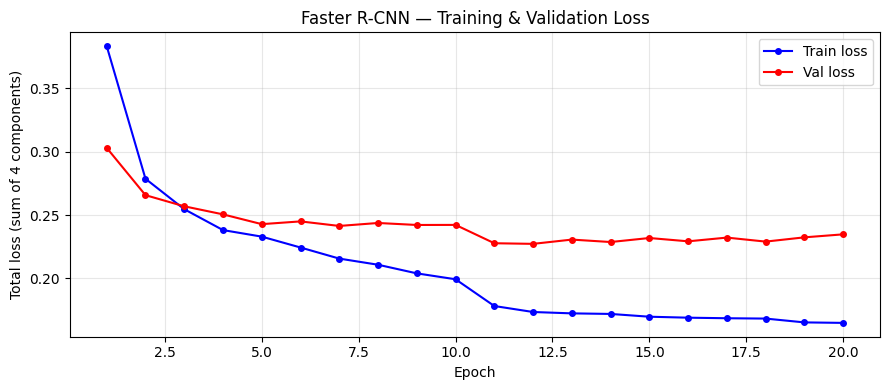

Saved → checkpoints/loss_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
epochs_x = range(1, len(train_losses) + 1)
ax.plot(epochs_x, train_losses, 'b-o', markersize=4, label='Train loss')
ax.plot(epochs_x, val_losses,   'r-o', markersize=4, label='Val loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total loss (sum of 4 components)')
ax.set_title('Faster R-CNN — Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'loss_curves.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/loss_curves.png')


## 10. Evaluation — mAP@0.5 and Per-Class AP

We load the **best checkpoint** (lowest val loss) and run COCO-standard mAP evaluation on the **validation split**.

**Metrics we report:**
- `mAP@0.5` — PASCAL VOC standard, IoU threshold 0.5
- Per-class AP — one number per class, revealing how badly RBC dominance hurts rare classes

**What to expect:**
- RBC AP will be moderate-to-high (lots of training examples)
- Gametocyte / Schizont AP will be low or 0 (too few examples, no imbalance correction)
- Ring AP will be low (visually similar to healthy RBC)

These numbers are the quantitative motivation for Pipeline B.


In [9]:
import json, sys
from pathlib import Path
from collections import defaultdict

import torch
from torch.utils.data import DataLoader, random_split
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import torchvision.transforms as T
from PIL import Image

# ── Paths ──────────────────────────────────────────────────────
ROOT     = Path('.').resolve().parent   # adjust if running from a different folder
CKPT_DIR = ROOT / 'Phase2-BaselineA' / 'checkpoints'
JSON_TRAIN = ROOT / 'data' / 'malaria' / 'training.json'
IMG_DIR    = ROOT / 'data' / 'malaria' / 'images'

# ── Label map ──────────────────────────────────────────────────
LABEL_TO_INT = {
    'background': 0, 'red blood cell': 1, 'trophozoite': 2,
    'ring': 3, 'schizont': 4, 'gametocyte': 5, 'leukocyte': 6,
}
INT_TO_LABEL     = {v: k for k, v in LABEL_TO_INT.items()}
NUM_CLASSES      = 7
PARASITE_CLASSES = ['trophozoite', 'ring', 'schizont', 'gametocyte']
SKIP_LABELS      = {'difficult'}

# ── Dataset (inline) ───────────────────────────────────────────
class MalariaDataset(torch.utils.data.Dataset):
    def __init__(self, json_path, image_dir):
        self.image_dir = Path(image_dir)
        self.transform = T.ToTensor()
        with open(json_path) as f:
            raw = json.load(f)
        self._records = []
        for item in raw:
            img_name = Path(item['image']['pathname']).name
            boxes, labels = [], []
            for obj in item.get('objects', []):
                lbl = obj['category']
                if lbl in SKIP_LABELS or lbl not in LABEL_TO_INT:
                    continue
                bb = obj['bounding_box']
                x1, y1 = float(bb['minimum']['c']), float(bb['minimum']['r'])
                x2, y2 = float(bb['maximum']['c']), float(bb['maximum']['r'])
                if x2 <= x1 or y2 <= y1:
                    continue
                boxes.append([x1, y1, x2, y2])
                labels.append(LABEL_TO_INT[lbl])
            if boxes:
                self._records.append({'img_name': img_name,
                                       'boxes': boxes, 'labels': labels})

    def __len__(self): return len(self._records)

    def __getitem__(self, idx):
        rec   = self._records[idx]
        image = Image.open(self.image_dir / rec['img_name']).convert('RGB')
        image = self.transform(image)
        return image, {
            'boxes':    torch.as_tensor(rec['boxes'],  dtype=torch.float32),
            'labels':   torch.as_tensor(rec['labels'], dtype=torch.int64),
            'image_id': torch.tensor([idx], dtype=torch.int64),
        }

def detection_collate(batch):
    return tuple(zip(*batch))

# ── Device ─────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Val loader ─────────────────────────────────────────────────
full_ds = MalariaDataset(JSON_TRAIN, IMG_DIR)
n_val   = int(len(full_ds) * 0.2)
n_train = len(full_ds) - n_val
gen     = torch.Generator().manual_seed(42)
_, val_ds = random_split(full_ds, [n_train, n_val], generator=gen)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False,
                        num_workers=0, collate_fn=detection_collate)
print(f'Val images: {len(val_ds)}')

# ── Rebuild model ──────────────────────────────────────────────
model = fasterrcnn_resnet50_fpn(weights=None)
in_feat = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_feat, NUM_CLASSES)

# ── Load checkpoint ────────────────────────────────────────────
ckpt = torch.load(CKPT_DIR / 'best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
model.to(device)
print(f'Loaded checkpoint — epoch {ckpt["epoch"]}, val_loss {ckpt["val_loss"]:.4f}')

# ── mAP evaluation ─────────────────────────────────────────────
@torch.no_grad()
def compute_map(model, loader, device, score_thresh=0.3):
    model.eval()
    metric = MeanAveragePrecision(iou_thresholds=[0.5], class_metrics=True)
    for images, targets in loader:
        images = [img.to(device) for img in images]
        preds  = model(images)
        filtered = []
        for p in preds:
            keep = p['scores'] >= score_thresh
            filtered.append({'boxes':  p['boxes'][keep].cpu(),
                             'scores': p['scores'][keep].cpu(),
                             'labels': p['labels'][keep].cpu()})
        cpu_tgts = [{'boxes': t['boxes'].cpu(), 'labels': t['labels'].cpu()}
                    for t in targets]
        metric.update(filtered, cpu_tgts)
    return metric.compute()

print('\nRunning mAP@0.5 — this takes a few minutes ...')
result = compute_map(model, val_loader, device)

map50 = result['map_50'].item()
print(f'\n{"="*50}')
print(f'  mAP@0.5 : {map50:.4f}  ({100*map50:.1f}%)')
print(f'{"="*50}')

metrics_out = {
    'map_50': round(map50, 4),
    'checkpoint_epoch': ckpt['epoch'],
    'val_loss': round(ckpt['val_loss'], 4),
}

if 'map_per_class' in result and result['map_per_class'] is not None:
    per = result['map_per_class'].tolist()
    metrics_out['per_class_ap'] = {}
    print(f'\n  {"Class":<22} {"AP@0.5":>8}')
    print('  ' + '-'*32)
    for i, ap in enumerate(per):
        cls  = INT_TO_LABEL.get(i + 1, f'class_{i+1}')
        flag = '  ← rare' if cls in PARASITE_CLASSES and cls != 'trophozoite' else ''
        metrics_out['per_class_ap'][cls] = round(ap, 4)
        print(f'  {cls:<22} {ap:>8.4f}{flag}')

with open(CKPT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=2)
print(f'\nSaved → {CKPT_DIR}/metrics.json')

Device: cuda
Val images: 241


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\taiba/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth
100.0%


Loaded checkpoint — epoch 12, val_loss 0.2273

Running mAP@0.5 — this takes a few minutes ...

  mAP@0.5 : 0.5846  (58.5%)

  Class                    AP@0.5
  --------------------------------
  red blood cell           0.9101
  trophozoite              0.6273
  ring                     0.5829  ← rare
  schizont                 0.3379  ← rare
  gametocyte               0.2351  ← rare
  leukocyte                0.8141

Saved → D:\MalariAI-Automated-Malaria-Cell-Segmentation-from-Blood-Smear-Images\Phase2-BaselineA\checkpoints/metrics.json


## 11. Qualitative Inference — Model Predictions vs Ground Truth

Visual check: does the model find cells at all? Do predictions align with GT boxes?

We show 4 validation images with:
- **Top row:** Ground-truth boxes (coloured by class)
- **Bottom row:** Model predictions (score ≥ threshold, coloured by class)

Look for:
- Are RBCs being detected? (should be mostly yes)
- Are parasitic stages being detected? (likely poor for ring/schizont/gametocyte)
- Do predicted boxes align spatially with GT? (rough alignment is expected)


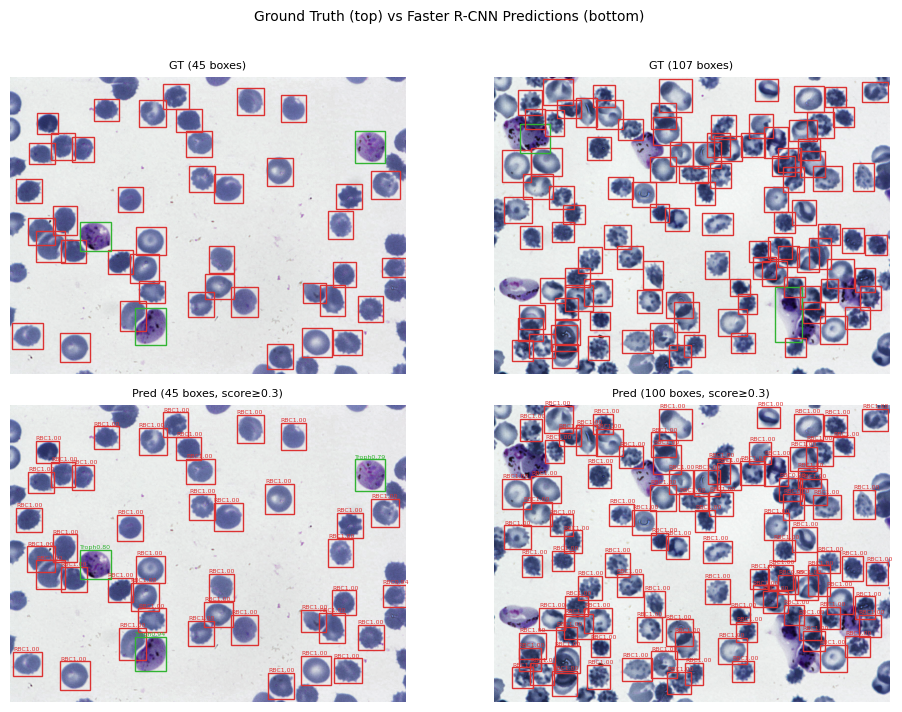

Saved → checkpoints/gt_vs_pred.png


In [14]:
model.eval()
sample_batch = next(iter(val_loader))
sample_imgs, sample_tgts = sample_batch
sample_imgs = [img.to(device) for img in sample_imgs]

with torch.no_grad():
    preds = model(sample_imgs)

n_show = min(len(sample_imgs), 4)
fig, axes = plt.subplots(2, n_show, figsize=(5*n_show, 7))
if n_show == 1: axes = axes.reshape(2, 1)

for col in range(n_show):
    img_np = sample_imgs[col].cpu().permute(1, 2, 0).numpy()

    # Top: GT
    ax_gt = axes[0, col]
    ax_gt.imshow(img_np)
    gt_boxes  = sample_tgts[col]['boxes'].numpy()
    gt_labels = sample_tgts[col]['labels'].numpy()
    for box, lbl in zip(gt_boxes, gt_labels):
        cls_name = INT_TO_LABEL[lbl]
        r, g, b  = CLASS_COLOUR_RGB[cls_name]
        color    = (r/255, g/255, b/255)
        rect = patches.Rectangle(
            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
            linewidth=1, edgecolor=color, facecolor='none'
        )
        ax_gt.add_patch(rect)
    ax_gt.set_title(f'GT ({len(gt_boxes)} boxes)', fontsize=8)
    ax_gt.axis('off')

    # Bottom: Predictions
    ax_pred = axes[1, col]
    ax_pred.imshow(img_np)
    pred_boxes  = preds[col]['boxes'].cpu().numpy()
    pred_labels = preds[col]['labels'].cpu().numpy()
    pred_scores = preds[col]['scores'].cpu().numpy()
    keep = pred_scores >= CFG['score_thresh']
    for box, lbl, score in zip(pred_boxes[keep], pred_labels[keep], pred_scores[keep]):
        cls_name = INT_TO_LABEL.get(lbl, 'background')
        r, g, b  = CLASS_COLOUR_RGB.get(cls_name, (128, 128, 128))
        color    = (r/255, g/255, b/255)
        rect = patches.Rectangle(
            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
            linewidth=1, edgecolor=color, facecolor='none'
        )
        ax_pred.add_patch(rect)
        ax_pred.text(box[0], max(box[1]-3,0), f'{SHORT_NAME.get(cls_name,"?")}{score:.2f}',
                     fontsize=4.5, color=color)
    ax_pred.set_title(f'Pred ({keep.sum()} boxes, score≥{CFG["score_thresh"]})', fontsize=8)
    ax_pred.axis('off')

plt.suptitle('Ground Truth (top) vs Faster R-CNN Predictions (bottom)', fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'gt_vs_pred.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved → checkpoints/gt_vs_pred.png')


## 12. Summary — What These Numbers Mean

### Interpreting the mAP results

| Expected range | Interpretation |
|---|---|
| `mAP@0.5 > 0.50` | Reasonable baseline — model finds cells |
| `mAP@0.5 < 0.30` | Model struggles — likely RBC-only detections |
| Gametocyte AP ≈ 0 | Expected — 144 training examples, no Focal Loss |
| Ring AP < RBC AP | Expected — visual similarity to healthy RBC |

### Why Pipeline B will improve on this

The Faster R-CNN baseline has three structural weaknesses baked in:

1. **P1 — Incomplete annotation:** The RPN was trained treating unannotated RBCs as background. Any RBC without a GT box suppressed the RPN's objectness score in that region. Our watershed Stage 1 has no such constraint — it finds cells purely from morphology.

2. **P2 — NMS:** Look at the prediction visualisations above. In any region where two cells overlap, Faster R-CNN can only keep one. Our distance-transform approach separates them before any scoring step.

3. **P3 — No XAI:** Faster R-CNN produces boxes and class labels. There is no mechanism to explain *why* a cell was classified as ring vs. trophozoite. Pipeline B adds Grad-CAM++ to every crop.

### Next step

The numbers from `checkpoints/metrics.json` go directly into **Table 3** of the paper (§5 Results). Save this file — it is the baseline row in every comparison table.

When you're ready: **→ Phase 3 (Pipeline B: Watershed + EfficientNet-B0 + Grad-CAM++).**


In [10]:
# Print final summary for the paper
with open(CKPT_DIR / 'metrics.json') as f:
    saved = json.load(f)

print('=' * 55)
print('PHASE 2 COMPLETE — Baseline A (Faster R-CNN)')
print('=' * 55)
print(f'  mAP@0.5         : {saved["map_50"]:.4f}')
print(f'  Best checkpoint : epoch {saved["checkpoint_epoch"]}')
print(f'  Val loss        : {saved["val_loss"]:.4f}')
if 'per_class_ap' in saved:
    print(f'\n  Per-class AP@0.5:')
    for cls, ap in saved['per_class_ap'].items():
        print(f'    {cls:<22} {ap:.4f}')
print('\nCheckpoints saved in Phase2-BaselineA/checkpoints/')
print('→ best.pth   (best val loss)')
print('→ latest.pth (last epoch)')
print('→ metrics.json')
print('→ loss_curves.png')
print('→ gt_vs_pred.png')


PHASE 2 COMPLETE — Baseline A (Faster R-CNN)
  mAP@0.5         : 0.5846
  Best checkpoint : epoch 12
  Val loss        : 0.2273

  Per-class AP@0.5:
    red blood cell         0.9101
    trophozoite            0.6273
    ring                   0.5829
    schizont               0.3379
    gametocyte             0.2351
    leukocyte              0.8141

Checkpoints saved in Phase2-BaselineA/checkpoints/
→ best.pth   (best val loss)
→ latest.pth (last epoch)
→ metrics.json
→ loss_curves.png
→ gt_vs_pred.png
